In [1]:
import torch

In [2]:
# # Commented out - bing_image_downloader is incompatible with Python 3.14+ (imghdr module removed from stdlib)
# # Ensure you have images in your dataset directory manually or using an alternative downloader

# from bing_image_downloader import downloader

# downloader.download(
#     query="마동석",
#     limit=50,
#     output_dir="./",
#     adult_filter_off=True,
#     force_replace=False,
#     timeout=30,
# )
# downloader.download(
#     query="카리나",
#     limit=50,
#     output_dir="./",
#     adult_filter_off=True,
#     force_replace=False,
#     timeout=30,
# )
# downloader.download(
#     query="장원영",
#     limit=50,
#     output_dir="./",
#     adult_filter_off=True,
#     # force_replace=False,
#     timeout=30,
# )

ModuleNotFoundError: No module named 'imghdr'

In [35]:
import os, shutil


def dataset_split(query, train_cnt):
    # Check if source directory exists
    if not os.path.exists(query):
        print(f"Warning: Directory '{query}' not found. Skipping...")
        return

    directory_list = [
        "./dataset/train/",
        "./dataset/test/",
    ]

    for dir in directory_list:
        if not os.path.isdir(dir + query):  # ./dataset/train/마동석
            os.makedirs(dir + query)

    cnt = 0
    for file_name in os.listdir(query):
        if cnt < train_cnt:
            print(f"trainset : {file_name}")
            shutil.move(
                query + "/" + file_name, "./dataset/train/" + query + "/" + file_name
            )
        else:
            print(f"testset : {file_name}")
            shutil.move(
                query + "/" + file_name, "./dataset/test/" + query + "/" + file_name
            )

        cnt += 1

    shutil.rmtree(query)


dataset_split("마동석", 40)
dataset_split("카리나", 40)
dataset_split("장원영", 40)


In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import time

In [37]:
transform_train = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

transform_test = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]
)

In [38]:
train_datasets = datasets.ImageFolder(root="./dataset/train", transform=transform_train)
test_datasets = datasets.ImageFolder(root="./dataset/test", transform=transform_test)

In [39]:
train_datasets.classes

['마동석', '장원영', '카리나']

In [40]:
len(train_datasets[0])

2

In [41]:
img, label = train_datasets[90]
label

1

In [42]:
import matplotlib.pyplot as plt


def imshow(img, title):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img = img.permute(1, 2, 0)  # 역정규화
    img = img * std + mean
    plt.title(title)
    plt.imshow(img)
    plt.show()

In [43]:
train_loader = torch.utils.data.DataLoader(train_datasets, shuffle=True, batch_size=4)
test_loader = torch.utils.data.DataLoader(test_datasets, shuffle=True, batch_size=4)

In [44]:
iter = iter(train_loader)
imgs, labels = next(iter)
out_imgs = torchvision.utils.make_grid(imgs)

imshow(out_imgs, labels)

TypeError: '_SingleProcessDataLoaderIter' object is not callable

In [ ]:
model = models.resnet34(pretrained=True)
model

c:\ml_proj4\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\ml_proj4\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
for name, module in model.named_parameters():
    print(name, module.requires_grad)

conv1.weight True
bn1.weight True
bn1.bias True
layer1.0.conv1.weight True
layer1.0.bn1.weight True
layer1.0.bn1.bias True
layer1.0.conv2.weight True
layer1.0.bn2.weight True
layer1.0.bn2.bias True
layer1.1.conv1.weight True
layer1.1.bn1.weight True
layer1.1.bn1.bias True
layer1.1.conv2.weight True
layer1.1.bn2.weight True
layer1.1.bn2.bias True
layer1.2.conv1.weight True
layer1.2.bn1.weight True
layer1.2.bn1.bias True
layer1.2.conv2.weight True
layer1.2.bn2.weight True
layer1.2.bn2.bias True
layer2.0.conv1.weight True
layer2.0.bn1.weight True
layer2.0.bn1.bias True
layer2.0.conv2.weight True
layer2.0.bn2.weight True
layer2.0.bn2.bias True
layer2.0.downsample.0.weight True
layer2.0.downsample.1.weight True
layer2.0.downsample.1.bias True
layer2.1.conv1.weight True
layer2.1.bn1.weight True
layer2.1.bn1.bias True
layer2.1.conv2.weight True
layer2.1.bn2.weight True
layer2.1.bn2.bias True
layer2.2.conv1.weight True
layer2.2.bn1.weight True
layer2.2.bn1.bias True
layer2.2.conv2.weight True


In [ ]:
for params in model.parameters():
    params.requires_grad = False

In [ ]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
model.fc = nn.Linear(512, 3)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
from torch.utils.data import random_split

train_data_size = len(train_datasets)

# 8:2  train:8   test:2
train_size = int(train_data_size * 0.8)
val_size = train_data_size - train_size

print(f"train data size : {train_size}    val data size : {val_size}")

train_dataset, val_dataset = random_split(train_datasets, [train_size, val_size])

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=4, shuffle=True
)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=4, shuffle=True)

train data size : 192    val data size : 48


In [ ]:
import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
epochs = 20
model = model.to(device)
best_val_loss = 100000
stop_count = 3
early_stop_count = 0


for epoch in range(epochs):
    model.train()
    for img, labels in tqdm.tqdm(train_dataloader):
        optimizer.zero_grad()
        preds = model(img.to(device))
        loss = criterion(preds, labels.to(device))
        loss.backward()
        optimizer.step()

    # -------  validation  모의고사 시작 -----------------
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for img, labels in val_dataloader:
            img = img.to(device)
            labels = labels.to(device)
            pred = model(img)
            val_loss += criterion(pred, labels)

    total_val_loss = val_loss / len(val_dataloader)

    # -------- Early Stopping 할것인지 체크

    if total_val_loss < best_val_loss:
        early_stop_count = 0
        best_val_loss = total_val_loss
        torch.save(model.state_dict(), "best_model.pth")
    else:
        early_stop_count += 1

        if early_stop_count >= stop_count:
            break

    print(loss.item())

100%|██████████| 48/48 [00:03<00:00, 12.85it/s]


1.0860731601715088


100%|██████████| 48/48 [00:03<00:00, 13.67it/s]


1.1317570209503174


100%|██████████| 48/48 [00:04<00:00, 11.40it/s]


...

0.6095137596130371


100%|██████████| 48/48 [00:05<00:00,  9.31it/s]


1.0095176696777344


 50%|█████     | 24/48 [00:02<00:02,  9.07it/s]


KeyboardInterrupt: 

tensor([0, 0, 2, 0])


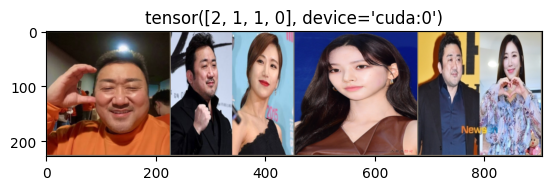

tensor([2, 2, 2, 0])


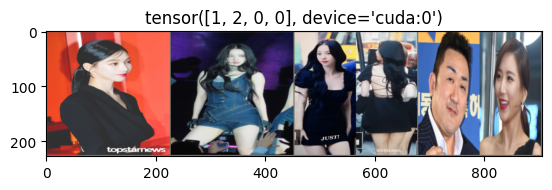

tensor([0, 1, 0, 0])


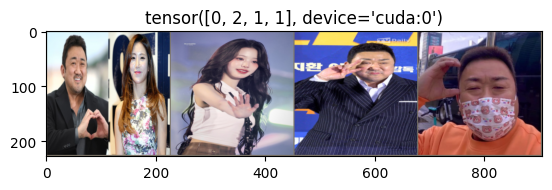

tensor([1, 2, 1, 0])


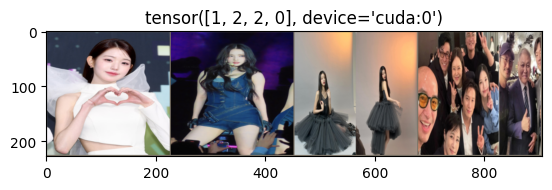

tensor([1, 2, 1, 2])


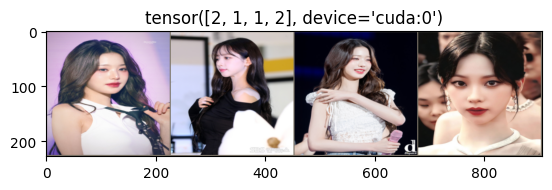

tensor([1, 2, 0, 0])


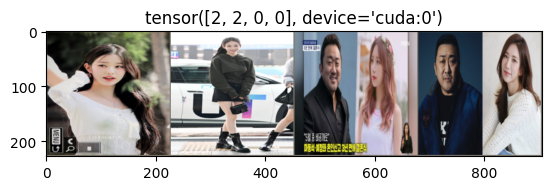

tensor([1, 2, 1, 2])


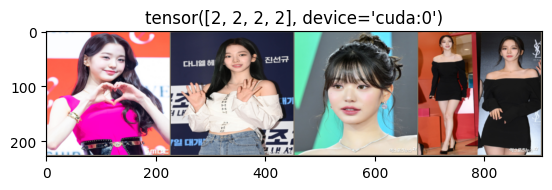

tensor([1, 1])


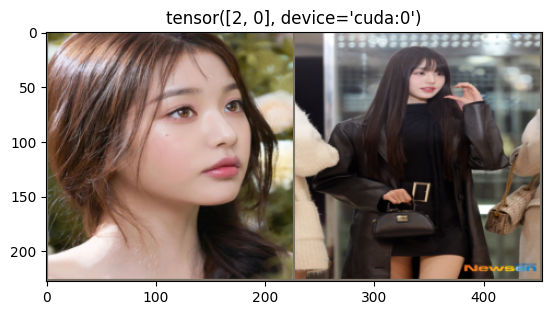

정확도 :  0.4666666666666667


In [ ]:
model.eval()
with torch.no_grad():
    corrects = 0

    for img, labels in test_loader:
        preds = model(img.to(device))
        pred = torch.max(preds, 1)[1]

        corrects += (pred == labels.to(device)).sum().item()
        img_grid = torchvision.utils.make_grid(img)

        print(labels)
        imshow(img_grid.cpu(), title=pred)

    acc = corrects / len(test_datasets.targets)
    print("정확도 : ", acc)


In [ ]:
for name, grad in model.layer4.named_parameters():
    print(name, grad.requires_grad)

0.conv1.weight False
0.bn1.weight False
0.bn1.bias False
0.conv2.weight False
0.bn2.weight False
0.bn2.bias False
0.downsample.0.weight False
0.downsample.1.weight False
0.downsample.1.bias False
1.conv1.weight False
1.bn1.weight False
1.bn1.bias False
1.conv2.weight False
1.bn2.weight False
1.bn2.bias False
2.conv1.weight False
2.bn1.weight False
2.bn1.bias False
2.conv2.weight False
2.bn2.weight False
2.bn2.bias False


In [ ]:
model = models.resnet34(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

model.fc = nn.Linear(512, 3)

In [ ]:
# 데이터셋 이미지 정규화 확인하는 방법
normal_imgs = [item[0] for item in train_datasets]
normal_imgs = torch.stack(normal_imgs, dim=0).numpy()
normal_imgs.shape

(120, 3, 224, 224)

In [ ]:
mean_r = imgs[:, 0, :, :].mean()
mean_g = imgs[:, 1, :, :].mean()
mean_b = imgs[:, 2, :, :].mean()

std_r = imgs[:, 0, :, :].std()
std_g = imgs[:, 1, :, :].std()
std_b = imgs[:, 2, :, :].std()

print("평균 : ", mean_r, mean_g, mean_b)
print("표준편차 : ", std_r, std_g, std_b)

평균 :  tensor(0.7857) tensor(0.2800) tensor(0.5907)
표준편차 :  tensor(1.4664) tensor(1.4794) tensor(1.4156)


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [ ]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
model = models.resnet34(pretrained=True)
model.fc = nn.Linear(512, 3)
model.load_state_dict(torch.load("best_model.pth", map_location="cpu"))

c:\hantorch\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\hantorch\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

In [ ]:
from PIL import Image

model.eval()
model.to("cuda")
img = Image.open("dataset/train/마동석/Image_17.jpg").convert("RGB")
input_tensor = transform_test(img).unsqueeze(0).to("cuda")

for param in model.parameters():
    param.requires_grad = True

pred = model(input_tensor)
pred_class = pred.argmax().item()
pred_class

0

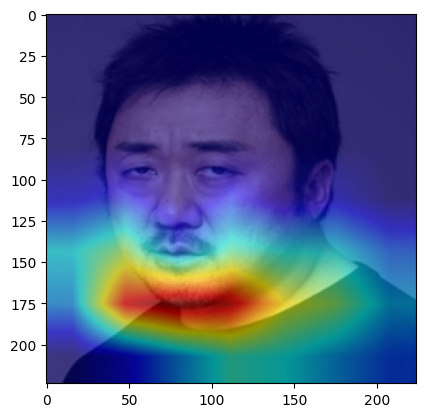

In [ ]:
import matplotlib.pyplot as plt

target_layers = [model.layer4[-1]]

cam = GradCAM(model=model, target_layers=target_layers)
grad_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_class)])[
    0
]

rgb_img = np.array(img.resize((224, 224))).astype(np.float32) / 255.0
visualization = show_cam_on_image(rgb_img, grad_cam, use_rgb=True)

plt.imshow(visualization)

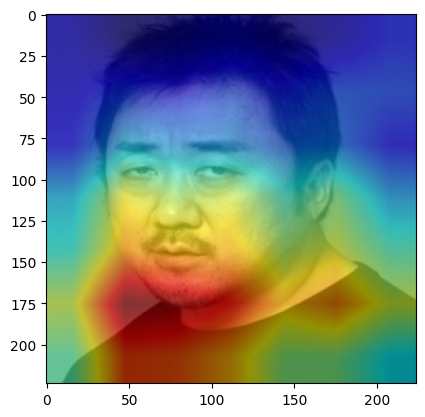

In [ ]:
from pytorch_grad_cam import GradCAMPlusPlus

cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

plusplus_cam = cam(
    input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_class)]
)[0]

rgb_img = np.array(img.resize((224, 224))).astype(np.float32) / 255.0
visualization = show_cam_on_image(rgb_img, plusplus_cam, use_rgb=True)

plt.imshow(visualization)
